In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!pip install -Uq transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 61.4 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 616.3/616.3 kB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 85.7 MB/s eta 0:00:00:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.1.1 requires transformers<5.0.0,>=4.41.0, but you have transformers 5.3.0 which is incompatible.
gradio 5.49.1 requires pydantic<2.12,>=2.0, but you have pydantic 2.12.5 which is incompatible.


In [3]:
# ── CELL 2: Imports ────────────────────────────────────
import os, random, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchaudio
import torchaudio.transforms as T
import torch.nn.functional as F
from tqdm.notebook import tqdm
from torch.utils.data import Dataset, DataLoader
from transformers import ASTForAudioClassification
warnings.filterwarnings('ignore')
print('Imports done!')

Imports done!


In [4]:
# ── CELL 3: CONFIG ─────────────────────────────────────

# Path to your trained checkpoint (.pt file)
MODEL_PT_PATH = '/kaggle/input/datasets/smrkamboj/best-ast-model/best_model_phase2.pth'

SAMPLE_RATE  = 16000
DURATION     = 20                  # must match training
MAX_LENGTH   = SAMPLE_RATE * DURATION

BATCH_SIZE   = 256                  # inference only — no gradients, use larger batch
NUM_WORKERS  = 4
PREFETCH     = 4

N_TTA        = 7                   # TTA crops per test file (try 7 for better score)

# SpecAugment params — must match training (used only to build GPUAudioTransform,
# augment=False at inference so these values don't affect predictions)
TIME_MASK_PARAM = 192
FREQ_MASK_PARAM = 48

BASE_PATH = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup"
# BASE_PATH = '/kaggle/input/competitions/jan-2026-dl-gen-ai-project/messy_mashup'

GENRES   = ['blues','classical','country','disco','hiphop',
            'jazz','metal','pop','reggae','rock']
label2id = {g: i for i, g in enumerate(GENRES)}
id2label = {i: g for g, i in label2id.items()}
NUM_LABELS = len(GENRES)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
N_GPUS = torch.cuda.device_count()
print(f'Device  : {DEVICE}')
print(f'N_TTA   : {N_TTA}')
print(f'Batch   : {BATCH_SIZE}')
print(f'Workers : {NUM_WORKERS}')

Device  : cuda
N_TTA   : 7
Batch   : 512
Workers : 4


In [5]:
def load_audio(path: str) -> torch.Tensor:
    """Load mono audio at SAMPLE_RATE.  Returns float32 Tensor (T,)."""
    waveform, sr = torchaudio.load(path)
    if sr != SAMPLE_RATE:
        waveform = torchaudio.functional.resample(waveform, sr, SAMPLE_RATE)
    if waveform.shape[0] > 1:
        waveform = waveform.mean(0, keepdim=True)
    return waveform.squeeze(0)

def normalize(audio: torch.Tensor) -> torch.Tensor:
    return audio / (audio.abs().max() + 1e-6)

def crop_random(audio: torch.Tensor) -> torch.Tensor:
    """Random crop — training augmentation."""
    length = audio.shape[0]
    if length >= MAX_LENGTH:
        start = random.randint(0, length - MAX_LENGTH)
        return audio[start : start + MAX_LENGTH]
    return F.pad(audio, (0, MAX_LENGTH - length))

In [6]:
# ── CELL 5: GPU Audio Transform ────────────────────────
# Converts a batch of raw waveforms → AST-compatible log-mel spectrograms
# entirely on GPU. Must match the transform used during training.

class GPUAudioTransform(nn.Module):
    AST_MEAN        = -4.2677393
    AST_STD         =  4.5689974
    AST_TIME_FRAMES = 1024

    def __init__(
        self,
        sample_rate     = SAMPLE_RATE,
        n_mels          = 128,
        n_fft           = 400,
        hop_length      = 313,
        f_min           = 50.0,
        f_max           = 8000.0,
        time_mask_param = TIME_MASK_PARAM,
        freq_mask_param = FREQ_MASK_PARAM,
    ):
        super().__init__()
        self.mel_spec = T.MelSpectrogram(
            sample_rate = sample_rate,
            n_fft       = n_fft,
            hop_length  = hop_length,
            n_mels      = n_mels,
            f_min       = f_min,
            f_max       = f_max,
            power       = 2.0,
            center      = True,
        )
        self.amplitude_to_db = T.AmplitudeToDB(stype='power', top_db=80)
        # SpecAugment layers — defined for API consistency, never used at inference
        self.time_mask_1 = T.TimeMasking(time_mask_param, iid_masks=True)
        self.time_mask_2 = T.TimeMasking(time_mask_param, iid_masks=True)
        self.freq_mask_1 = T.FrequencyMasking(freq_mask_param, iid_masks=True)
        self.freq_mask_2 = T.FrequencyMasking(freq_mask_param, iid_masks=True)

    def forward(self, waveforms: torch.Tensor, augment: bool = False) -> torch.Tensor:
        spec = self.mel_spec(waveforms)                    # (B, n_mels, T_frames)
        spec = self.amplitude_to_db(spec)
        # Pad or truncate to exactly 1024 frames (AST positional embedding size)
        T_frames = spec.shape[2]
        if T_frames > self.AST_TIME_FRAMES:
            spec = spec[:, :, :self.AST_TIME_FRAMES]
        elif T_frames < self.AST_TIME_FRAMES:
            spec = torch.nn.functional.pad(spec, (0, self.AST_TIME_FRAMES - T_frames))
        spec = (spec - self.AST_MEAN) / (self.AST_STD * 2)
        if augment:
            spec = self.time_mask_1(spec)
            spec = self.time_mask_2(spec)
            spec = self.freq_mask_1(spec)
            spec = self.freq_mask_2(spec)
        return spec.transpose(1, 2)                        # (B, 1024, 128)

gpu_transform = GPUAudioTransform().to(DEVICE)
with torch.no_grad():
    dummy = torch.randn(2, MAX_LENGTH).to(DEVICE)
    out   = gpu_transform(dummy, augment=False)
    assert out.shape == (2, 1024, 128), f'Unexpected shape: {out.shape}'
print(f'GPUAudioTransform ready on {DEVICE}  |  output shape: {out.shape}')

GPUAudioTransform ready on cuda  |  output shape: torch.Size([2, 1024, 128])


In [7]:
# ── CELL 21: Pre-load Test Files to RAM (DataLoader) ───────────────────────
test_df    = pd.read_csv(os.path.join(BASE_PATH, 'test.csv'))
n_files    = len(test_df)
test_paths = [os.path.join(BASE_PATH, row['filename'])
              for _, row in test_df.iterrows()]

class _TestDataset(Dataset):
    def __init__(self, paths):
        self.paths = paths
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, i):
        try:
            return i, load_audio(self.paths[i]).half()
        except Exception:
            return i, None

print(f'Pre-loading {n_files} test files to RAM ({NUM_WORKERS} workers)...')
test_cache: dict[int, torch.Tensor] = {}

_test_loader = DataLoader(
    _TestDataset(test_paths),
    batch_size  = 1,
    num_workers = NUM_WORKERS,
    collate_fn  = lambda b: b[0],
    pin_memory  = False,
)
for idx, tensor in tqdm(_test_loader, desc='Test files'):
    if tensor is not None:
        test_cache[idx] = tensor

loaded_mb = sum(t.nbytes for t in test_cache.values()) / 1e6
print(f'Loaded {len(test_cache)}/{n_files} test files | {loaded_mb:.0f} MB (float16)')

Pre-loading 3020 test files to RAM (4 workers)...


Test files:   0%|          | 0/3020 [00:00<?, ?it/s]

Loaded 3020/3020 test files | 2769 MB (float16)


In [8]:
# ── CELL 22: TTA Inference Dataset ────────────────────────────────────────────

class TestTTADataset(Dataset):
    """
    Each item is one (file, tta_crop) pair.
    Total length = len(test_df) × N_TTA.
    Reads from test_cache — no disk I/O.
    """
    def __init__(self, test_df, n_tta=N_TTA):
        self.test_df = test_df
        self.n_tta   = n_tta
        self.n_files = len(test_df)

    def __len__(self):
        return self.n_files * self.n_tta

    def __getitem__(self, idx):
        file_idx = idx % self.n_files
        audio    = test_cache[file_idx].float()
        cropped  = crop_random(audio)
        cropped  = normalize(cropped)
        return file_idx, cropped

print(f'TestTTADataset defined! ({N_TTA} crops × {n_files} files = {N_TTA*n_files} items)')


tta_dataset = TestTTADataset(test_df, n_tta=N_TTA)
tta_loader  = DataLoader(
    tta_dataset,
    batch_size         = BATCH_SIZE,
    shuffle            = False,
    num_workers        = NUM_WORKERS,
    pin_memory         = True,
    persistent_workers = True,
    prefetch_factor    = PREFETCH,
)

TestTTADataset defined! (7 crops × 3020 files = 21140 items)


In [9]:
# # Load model directly
# from transformers import AutoFeatureExtractor, AutoModelForAudioClassification

# # extractor = AutoFeatureExtractor.from_pretrained("anand095/ast-finetuned-custom")
# model = AutoModelForAudioClassification.from_pretrained("anand095/ast-finetuned-custom")
# model.to(DEVICE)

# total_params = sum(p.numel() for p in model.parameters())
# print(f'Model loaded from : {MODEL_PT_PATH}')
# print(f'Total parameters  : {total_params:,}')
# print(f'Device            : {DEVICE}')

In [10]:
# ── CELL 6: Load Model from .pt Checkpoint ─────────────
# Builds the AST architecture (10-class head) then loads
# your trained weights — no HuggingFace download needed.

MODEL_NAME = 'MIT/ast-finetuned-audioset-10-10-0.4593'

model = ASTForAudioClassification.from_pretrained(
    MODEL_NAME,
    num_labels              = NUM_LABELS,
    id2label                = id2label,
    label2id                = label2id,
    ignore_mismatched_sizes = True,   # replaces 527-class head with 10-class
)

# Load your trained weights
state_dict = torch.load(MODEL_PT_PATH, map_location=DEVICE)
model.load_state_dict(state_dict)
model.to(DEVICE)
model.eval()

total_params = sum(p.numel() for p in model.parameters())
print(f'Model loaded from : {MODEL_PT_PATH}')
print(f'Total parameters  : {total_params:,}')
print(f'Device            : {DEVICE}')

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                          
------------------------+----------+------------------------------------------------------------------------------------------
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([527]) vs model:torch.Size([10])          
classifier.dense.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([527, 768]) vs model:torch.Size([10, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Model loaded from : /kaggle/input/datasets/smrkamboj/best-ast-model/best_model_phase2.pth
Total parameters  : 86,196,490
Device            : cuda


In [11]:
from torch.cuda.amp import autocast

# 1. Create a Wrapper Module
class TTAInferenceWrapper(nn.Module):
    def __init__(self, model, gpu_transform):
        super().__init__()
        self.model = model
        self.gpu_transform = gpu_transform

    def forward(self, waveforms):
        with torch.autocast(device_type='cuda', dtype=torch.float16):
            spec   = self.gpu_transform(waveforms, augment=False)
            logits = self.model(spec).logits
        return logits

# 2. Setup the Wrapper for Multi-GPU
wrapper = TTAInferenceWrapper(model, gpu_transform)

if N_GPUS > 1:
    wrapper = nn.DataParallel(wrapper)
    print(f'DataParallel across {N_GPUS} GPUs')

wrapper.eval()

print(f'Best model loaded!')
print(f'Test samples: {n_files}  |  TTA: ×{N_TTA}  |  Total items: {n_files * N_TTA}')

prob_accum = torch.zeros(n_files, NUM_LABELS, dtype=torch.float32)

# 3. Clean Inference Loop
with torch.no_grad():
    for file_indices, waveforms in tqdm(tta_loader, desc=f'Inference (TTA ×{N_TTA})'):
        # Only send inputs to the base device; DataParallel handles the scattering
        waveforms = waveforms.to(DEVICE, non_blocking=True)
        
        # The wrapper takes care of autocast and scattering automatically
        logits = wrapper(waveforms)
        
        probs = torch.softmax(logits.float(), dim=1).cpu()
        prob_accum.index_add_(0, file_indices.long(), probs)

prob_accum /= N_TTA
pred_ids    = prob_accum.argmax(dim=1).tolist()

submission = pd.DataFrame({'id': test_df['id'].tolist(),
                           'genre': [id2label[p] for p in pred_ids]})
submission.to_csv('/kaggle/working/submission.csv', index=False)

print(f'\nSubmission saved!')
print(f'Total predictions : {len(submission)}')
print(f'\nFirst 5 predictions:\n{submission.head()}')

DataParallel across 2 GPUs
Best model loaded!
Test samples: 3020  |  TTA: ×7  |  Total items: 21140


Inference (TTA ×7):   0%|          | 0/42 [00:00<?, ?it/s]


Submission saved!
Total predictions : 3020

First 5 predictions:
   id    genre
0   1      pop
1   2     jazz
2   3    disco
3   4    metal
4   5  country


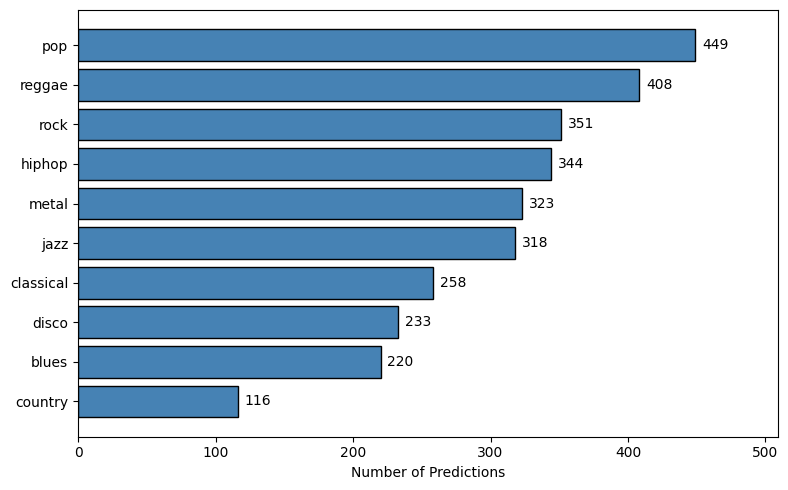

In [12]:
# ── CELL 24: Genre Distribution Plot ──────────────────────────────────────────
import matplotlib.pyplot as plt

genre_counts = submission['genre'].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(genre_counts.index, genre_counts.values, color='steelblue', edgecolor='black')

for bar, val in zip(bars, genre_counts.values):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=10)

ax.set_xlabel('Number of Predictions')
# ax.set_title(f'Genre Distribution — {MODEL.upper()} (n={len(submission)})')
ax.set_xlim(0, genre_counts.max() + 60)
plt.tight_layout()
plt.savefig('/kaggle/working/genre_distribution.png', dpi=150)
plt.show()
